In this notebook we want to explore performing "Trotter cosistent" truncations within a Trotter step, while imposing a more stringent truncation after each Trotter step.

In [2]:
using Revise
using MajoranaPropagation
using PauliPropagation

using Base.Threads

using Plots

nthreads()

4

We study the dynamics of $5\times 5$ Fermi-Hubbard in the strongly interacting regime $U/t=8$

In [3]:
N_x = 5
N_y = 5
N_spinful_sites = N_x * N_y
t = 1.
U = 8.

n_layers = 15
dt = 0.07;

For simplicity we restrict ourselves to a 1st order Trotterization of the Hamiltonian 

In [4]:
topo = rectangletopology(N_x, N_y)

circ_single = []
thetas_single = []

#up hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopup, [i, j]))
    push!(thetas_single, -t * dt)
end

#down hoppings 
for (i, j) in topo
    push!(circ_single, FermionicGate(:hopdn, [i, j]))
    push!(thetas_single, -t * dt)
end

#on-site repulsion 
for i = 1:N_spinful_sites
    push!(circ_single, FermionicGate(:nupndn, i))
    push!(thetas_single, U * dt)
end

We set the truncations: crucially, we want to explore the difference between always truncating strings with more than 4 unpaired Majoranas versus allowing 6 unpaired Majoranas within each Trotter step and truncating with 4 unpaired only after the full step. Notice that by the properties of the Fermi-Hubbard Hamiltonian the process of going from 4 unpaired to 6 and then back to 4 happens at order $(\delta t)^2$, hence happens at the same order of the Trotter error, since we are using a 1st order Trotterization

In [5]:
min_abs_coeff = 5.e-5
max_unpaired = 4
max_unpaired_in_step = 6;

As initial state we select a checkerboard state with a hole in the middle

In [6]:
#initial state 
initial_state_label = "Hole checkerboard"
is_spinful = true

hole_pos = 13

fock_state = fockstate(N_spinful_sites, :checkerboard, is_spinful; nx=N_x, hole_positions=hole_pos)

fock_state

fockstate([1, 4, 5, 8, 9, 12, 13, 16, 17, 20  …  32, 33, 36, 37, 40, 41, 44, 45, 48, 49], true)

Here we propagate the same oservable tracking the probability of finding the hole in its original position using the two approaches, while for the case of the "Trotter consistent" approach we truncate using the more stringent cutoff after each step.

In [7]:
obs = MajoranaSum(N_spinful_sites, :hole, hole_pos)
obs_trotter_consistent = MajoranaSum(N_spinful_sites, :hole, hole_pos)

res = zeros(n_layers+1)
res_trotter_consistent = zeros(n_layers+1)

res[1] = overlapwithfock(obs, fock_state)
res_trotter_consistent[1] = overlapwithfock(obs_trotter_consistent, fock_state)

for k=1:n_layers
    print(k, " ")
    obs = propagate!(circ_single, obs, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired)
    obs_trotter_consistent = propagate!(circ_single, obs_trotter_consistent, thetas_single, min_abs_coeff=min_abs_coeff, max_unpaired=max_unpaired_in_step)

    MajoranaPropagation.checktruncationonall!(obs_trotter_consistent; min_abs_coeff=-1, max_unpaired=max_unpaired)

    res[k+1] = overlapwithfock(obs, fock_state)
    res_trotter_consistent[k+1] = overlapwithfock(obs_trotter_consistent, fock_state)
end 

1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 

Notice that the two expectation values are not that far from each other. However, both coefficient and unpaired truncations are here set quite aggressively (in order for this example to run in a reasonable time), and a much bigger difference is expected for more accurate truncations.

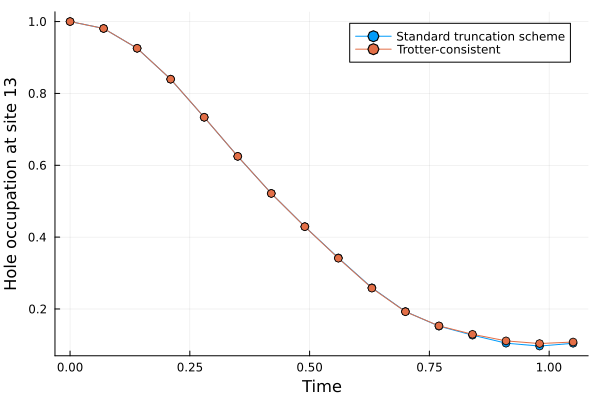

In [11]:
p = plot((0:n_layers) .* dt, res, label="Standard truncation scheme", marker=:o, xlabel="Time", ylabel="Hole occupation at site $hole_pos")
plot!((0:n_layers) .* dt, res_trotter_consistent, label="Trotter-consistent", marker=:o)